In [11]:
import math

import seaborn as sns
import torch
from matplotlib import pyplot as plt

sns.set()

from embedding.image_creation_funcs import riemann_distance, distance_center, geodesic, moebius

In [12]:
# check that poincare distance grows exponentially
lin = torch.linspace(0, 0.705, 1000)
zs = torch.complex(lin, lin).reshape(1000, 1)

distances = torch.vmap(distance_center, in_dims=(0))(zs)

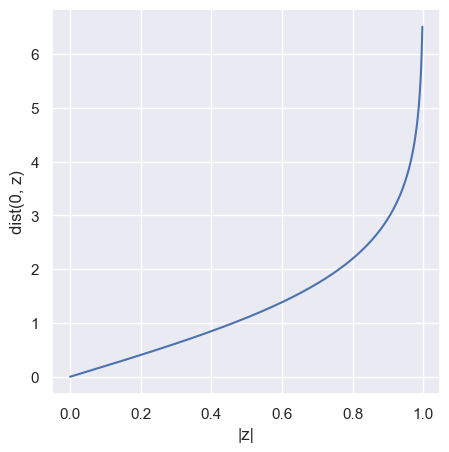

In [13]:
# plot distances from the center
plt.figure(figsize=(5, 5))
plt.plot(zs.abs(), distances)
plt.xlabel("|z|")
plt.ylabel("dist(0, z)")
plt.savefig("images/dist_exponential.png", dpi=500)
plt.show()

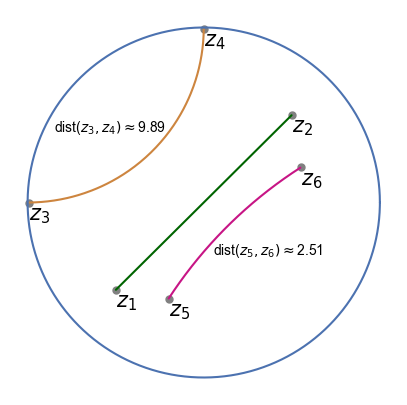

In [14]:
# create the sphere S^1 as the boudary of the poincare disk
x_sphere = torch.cos(torch.linspace(0, 2 * math.pi, 1000))
y_sphere = torch.sin(torch.linspace(0, 2 * math.pi, 1000))
sphere = torch.complex(x_sphere, y_sphere)

# create points in the disk
z1 = torch.complex(torch.tensor([-0.5]), torch.tensor([-0.5]))
z2 = torch.complex(torch.tensor([0.5]), torch.tensor([0.5]))
z3 = torch.complex(torch.tensor([-0.99]), torch.tensor([0.0]))
z4 = torch.complex(torch.tensor([0.0]), torch.tensor([0.99]))
z5 = torch.complex(torch.tensor([-0.2]), torch.tensor([-0.55]))
z6 = torch.complex(torch.tensor([0.55]), torch.tensor([0.2]))
points = {
    r"$z_1$": z1,
    r"$z_2$": z2,
    r"$z_3$": z3,
    r"$z_4$": z4,
    r"$z_5$": z5,
    r"$z_6$": z6,
}

# values the geodesic curve gets computed for
ts = torch.linspace(-2, 3, 1000).reshape(1000, 1)

# compute geodesics
geod_z1_z2 = torch.vmap(geodesic, in_dims=(None, None, 0, None))(z1, z2, ts, "disk")
geod_z3_z4 = torch.vmap(geodesic, in_dims=(None, None, 0, None))(z3, z4, ts, "disk")
geod_z5_z6 = torch.vmap(geodesic, in_dims=(None, None, 0, None))(z5, z6, ts, "disk")

# split into geodesic and arc
arc_z1_z2 = torch.tensor_split(geod_z1_z2[torch.where(geod_z1_z2.abs() >= z1.abs())], 2)
geod_z1_z2 = geod_z1_z2[torch.where(geod_z1_z2.abs() < z1.abs())]
arc_z3_z4 = torch.tensor_split(geod_z3_z4[torch.where(geod_z3_z4.abs() >= z3.abs())], 2)
geod_z3_z4 = geod_z3_z4[torch.where(geod_z3_z4.abs() < z3.abs())]
arc_z5_z6 = torch.tensor_split(geod_z5_z6[torch.where(geod_z5_z6.abs() >= z5.abs())], 2)
geod_z5_z6 = geod_z5_z6[torch.where(geod_z5_z6.abs() < z5.abs())]

# compute distances
dist_z3_z4 = riemann_distance(z3, z4)
dist_z5_z6 = riemann_distance(z5, z6)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(geod_z1_z2.real, geod_z1_z2.imag, color="darkgreen")
ax.plot(geod_z3_z4.real, geod_z3_z4.imag, color="peru")
ax.plot(geod_z5_z6.real, geod_z5_z6.imag, color="mediumvioletred")
ax.plot(sphere.real, sphere.imag)
ax.scatter(
    [z1.real, z2.real, z3.real, z4.real, z5.real, z6.real],
    [z1.imag, z2.imag, z3.imag, z4.imag, z5.imag, z6.imag],
    c="grey",
    s=25,
)
plt.axis("off")
for name, val in points.items():
    ax.annotate(name, (val.real, val.imag - 0.1), fontsize=15, c="black")

ax.annotate(
    r"dist($z_3, z_4) \approx $%.2f " % dist_z3_z4.item(),
    (-0.85, 0.4),
    fontsize=10,
    color="black",
)
ax.annotate(
    r"dist($z_5, z_6) \approx $%.2f " % dist_z5_z6.item(),
    (0.05, -0.3),
    fontsize=10,
    color="black",
)
plt.savefig("images/geodesics_disk.png", dpi=500)
plt.show()

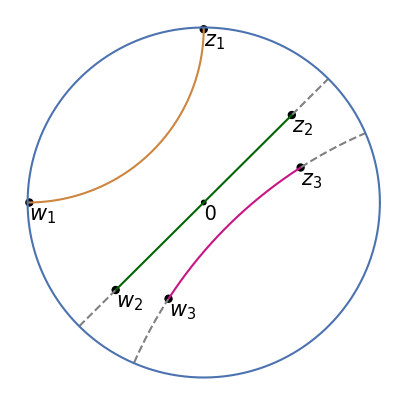

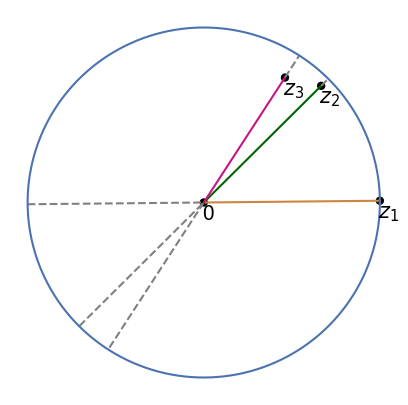

In [19]:
moeb_geod_z1_z2 = torch.vmap(moebius, in_dims=(0, None, None))(geod_z1_z2, z1, "disk")
moeb_arc_z1_z2_0 = torch.vmap(moebius, in_dims=(0, None, None))(arc_z1_z2[0], z1, "disk")
moeb_arc_z1_z2_1 = torch.vmap(moebius, in_dims=(0, None, None))(arc_z1_z2[1], z1, "disk")
moeb_z1, moeb_z2 = moebius(z1, z1, "disk"), moebius(z2, z1, "disk")
moeb_geod_z3_z4 = torch.vmap(moebius, in_dims=(0, None, None))(geod_z3_z4, z3, "disk")
moeb_arc_z3_z4_0 = torch.vmap(moebius, in_dims=(0, None, None))(arc_z3_z4[0], z3, "disk")
moeb_arc_z3_z4_1 = torch.vmap(moebius, in_dims=(0, None, None))(arc_z3_z4[1], z3, "disk")
moeb_z3, moeb_z4 = moebius(z3, z3, "disk"), moebius(z4, z3, "disk")
moeb_geod_z5_z6 = torch.vmap(moebius, in_dims=(0, None, None))(geod_z5_z6, z5, "disk")
moeb_arc_z5_z6_0 = torch.vmap(moebius, in_dims=(0, None, None))(arc_z5_z6[0], z5, "disk")
moeb_arc_z5_z6_1 = torch.vmap(moebius, in_dims=(0, None, None))(arc_z5_z6[1], z5, "disk")
moeb_z5, moeb_z6 = moebius(z5, z5, "disk"), moebius(z6, z5, "disk")

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
points = {
    "0": torch.complex(torch.zeros(1), torch.zeros(1)),
    r"$w_2$": z1,
    r"$z_2$": z2,
    r"$w_1$": z3,
    r"$z_1$": z4,
    r"$w_3$": z5,
    r"$z_3$": z6,
}

moeb_points = {
    "0": torch.complex(torch.zeros(1), torch.zeros(1)),
    r"$z_2$": moeb_z2,
    r"$z_1$": moeb_z4,
    r"$z_3$": moeb_z6,
}

ax.plot(geod_z1_z2.real, geod_z1_z2.imag, color="darkgreen")
ax.plot(geod_z3_z4.real, geod_z3_z4.imag, color="peru")
ax.plot(geod_z5_z6.real, geod_z5_z6.imag, color="mediumvioletred")
ax.plot(arc_z1_z2[0].real, arc_z1_z2[0].imag, color="grey", linestyle="dashed")
ax.plot(arc_z1_z2[1].real, arc_z1_z2[1].imag, color="grey", linestyle="dashed")
ax.plot(arc_z3_z4[0].real, arc_z3_z4[0].imag, color="grey", linestyle="dashed")
ax.plot(arc_z3_z4[1].real, arc_z3_z4[1].imag, color="grey", linestyle="dashed")
ax.plot(arc_z5_z6[0].real, arc_z5_z6[0].imag, color="grey", linestyle="dashed")
ax.plot(arc_z5_z6[1].real, arc_z5_z6[1].imag, color="grey", linestyle="dashed")
ax.plot(sphere.real, sphere.imag)
ax.scatter(
    [z1.real, z2.real, z3.real, z4.real, z5.real, z6.real, torch.zeros(1)],
    [z1.imag, z2.imag, z3.imag, z4.imag, z5.imag, z6.imag, torch.zeros(1)],
    c=["black", "black", "black", "black", "black", "black", "black"],
    s=[25, 25, 25, 25, 25, 25, 10]
)
ax.axis("off")
for name, val in points.items():
    ax.annotate(name, (val.real, val.imag - 0.1), fontsize=15, c="black")

plt.savefig("images/geodesics_with_arcs_disk.png", dpi=500)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(moeb_geod_z1_z2.real, moeb_geod_z1_z2.imag, color="darkgreen")
ax.plot(moeb_geod_z3_z4.real, moeb_geod_z3_z4.imag, color="peru")
ax.plot(moeb_geod_z5_z6.real, moeb_geod_z5_z6.imag, color="mediumvioletred")
ax.plot(moeb_arc_z1_z2_0.real, moeb_arc_z1_z2_0.imag, color="grey", linestyle="dashed")
ax.plot(moeb_arc_z1_z2_1.real, moeb_arc_z1_z2_1.imag, color="grey", linestyle="dashed")
ax.plot(moeb_arc_z3_z4_0.real, moeb_arc_z3_z4_0.imag, color="grey", linestyle="dashed")
ax.plot(moeb_arc_z3_z4_1.real, moeb_arc_z3_z4_1.imag, color="grey", linestyle="dashed")
ax.plot(moeb_arc_z5_z6_0.real, moeb_arc_z5_z6_0.imag, color="grey", linestyle="dashed")
ax.plot(moeb_arc_z5_z6_1.real, moeb_arc_z5_z6_1.imag, color="grey", linestyle="dashed")
ax.plot(sphere.real, sphere.imag)
ax.scatter(
    [moeb_z1.real, moeb_z2.real, moeb_z4.real, moeb_z6.real, torch.zeros(1)],
    [moeb_z1.imag, moeb_z2.imag, moeb_z4.imag, moeb_z6.imag, torch.zeros(1)],
    c=["black", "black", "black", "black", "black"],
    s=[25, 25, 25, 25, 10]
)
ax.axis("off")
for name, val in moeb_points.items():
    ax.annotate(name, (val.real-0.01, val.imag - 0.1), fontsize=15, c="black")

plt.savefig("images/moebius_with_arcs_disk.png", dpi=500)
plt.show()